# Modelo

Entrenamos un **Random Forest** (siguiendo `z401_Fuego_contra_fuego.ipynb`) sobre el dataset con las features nuevas de `clase4.ipynb` (`competencia_01_fe.csv`, 233 columnas). El notebook cubre:

1. La ecuacion de ganancia (de donde sale el `threshold` de decision).
2. Carga de datos y preparacion (imputacion, split train / futuro).
3. Optimizacion de hiperparametros con Optuna, usando **OOB score** como proxy rapido de la ganancia.
4. Entrenamiento del modelo final.
5. Criterios para elegir el modelo correcto: no un solo numero, sino una distribucion de ganancia sobre varias semillas, chequeo de overfitting train/futuro, y validacion de que el modelo se apoya en senal real (incluyendo si las features nuevas de `clase4` realmente aportan).


In [3]:
import os
import pickle
from time import time

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score

import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_slice, plot_contour


In [4]:
base_path = 'C:\\Users\\alejandro\\dmeyf2026\\monday\\'
#base_path = '/content/drive/MyDrive/DMEyF/2026/notebooks/'
dataset_path = base_path + 'data/'
modelos_path = base_path + 'modelos/'
db_path = base_path + 'data/'
dataset_file = 'competencia_01_fe.csv'  # generado por clase4.ipynb

os.makedirs(modelos_path, exist_ok=True)

ganancia_acierto = 1_072_500
costo_estimulo = 27_500

mes_train = 202104
mes_test = 202106

# agregue sus semillas
semilla = 17
np.random.seed(semilla)
semillas = np.random.choice(1_000_000, size=50, replace=False).tolist()

data = pd.read_csv(dataset_path + dataset_file)
data.shape


(983061, 233)

## La ecuacion de ganancia

El banco le ofrece un estimulo de retencion a los clientes que el modelo marca como probable `BAJA+2`. El estimulo cuesta `costo_estimulo` se acierte o no. Si el cliente realmente se iba (`BAJA+2`) y el estimulo lo retiene, el banco gana `ganancia_acierto`.

Para un cliente con probabilidad estimada `p` de ser `BAJA+2`, la ganancia esperada de estimularlo es:

`ganancia_esperada(p) = p * ganancia_acierto - (1 - p) * costo_estimulo`

Conviene estimular solo cuando esa ganancia esperada es positiva:

`p * ganancia_acierto - (1 - p) * costo_estimulo > 0`

`p * (ganancia_acierto + costo_estimulo) > costo_estimulo`

`p > costo_estimulo / (ganancia_acierto + costo_estimulo)`

Ese cociente es el `threshold` que venimos usando en `ganancia()` / `ganancia_prob()` desde `z301`. No es un numero magico: sale directo de la ecuacion economica del problema.


In [5]:
THRESHOLD = costo_estimulo / (ganancia_acierto + costo_estimulo)
print(f"Threshold de decision: {THRESHOLD}")

def ganancia_prob(y_hat, y, prop=1, class_index=1, threshold=THRESHOLD):
    @np.vectorize
    def ganancia_row(predicted, actual):
        return (predicted >= threshold) * (ganancia_acierto if actual == "BAJA+2" else -costo_estimulo)

    return ganancia_row(y_hat[:, class_index], y).sum() / prop


Threshold de decision: 0.025


## Datos: train y futuro

Igual que en `z301`/`z401`, reservamos un mes exclusivamente para la evaluacion final y no lo tocamos durante la busqueda de hiperparametros. Pero elegir `mes_train`/`mes_test` en este dataset tiene dos restricciones nuevas que `z301`/`z401` no tenian (porque no usaban features de tendencia):

**1) Las features de tendencia necesitan historia previa.** `z301`/`z401` usaban `mes_train = 202103` (Marzo), el **primer mes que existe en todo el dataset** — para ese mes ningun cliente tiene 'mes anterior'. Nuestras `lag_1_*`, `delta_1_*`, `slope_3_*` dependen de al menos un mes previo, asi que en `202103` esas ~39 columnas quedarian **enteramente nulas** y `SimpleImputer` las descartaria en silencio, rompiendo el alineamiento de columnas entre train y futuro. Conclusion: `mes_train` no puede ser `202103`.

**2) `clase_ternaria` necesita 2 meses de futuro para poder distinguir `BAJA+2` de `CONTINUA`.** El dataset llega hasta `202108`. Revisando la distribucion de `clase_ternaria` por mes, `202107` y `202108` tienen la clase en `None` (no hay suficiente futuro en el csv para saber si esos clientes se dieron de baja o no). Los unicos meses con etiqueta completa y confiable son `202103` a `202106`. Conclusion: ni `mes_train` ni `mes_test` pueden ser `202107` u `202108`.

Combinando ambas restricciones, el rango valido para los dos es `202104`-`202106`. Usamos `mes_train = 202104` (tiene a `202103` como unico mes previo, suficiente para `lag_1`/`delta_1`, y da 2 puntos para `slope_3`) y `mes_test = 202106` (misma brecha de 2 meses que usaba la catedra, y con etiqueta 100% valida).


In [6]:
X = data[data['foto_mes'] == mes_train]
y = X['clase_ternaria']
X = X.drop(columns=['clase_ternaria'])

X_futuro = data[data['foto_mes'] == mes_test]
y_futuro = X_futuro['clase_ternaria']
X_futuro = X_futuro.drop(columns=['clase_ternaria'])

print('train:', X.shape, ' futuro:', X_futuro.shape)


train: (163284, 232)  futuro: (164114, 232)


## Imputacion

`RandomForestClassifier` no soporta `NaN`. Ademas, nuestras features de tendencia (`lag_1_*`, `delta_1_*`, `slope_3_*`, `ma_3_*`) van a tener nulls por diseno en el primer mes de cada cliente (no existe mes anterior). Imputamos con la mediana.

A diferencia de `z401` (que hace `fit_transform` por separado en train y en futuro, ajustando una mediana distinta para cada mes), acá ajustamos el imputer una sola vez sobre train y lo aplicamos tal cual a futuro — si no, estariamos introduciendo otra fuente de drift entre train y futuro, ademas de la inflacion que ya discutimos en `clase4`.


In [7]:
imp_median = SimpleImputer(missing_values=np.nan, strategy='median')
Xi = imp_median.fit_transform(X)
Xif = imp_median.transform(X_futuro)


## Optimizacion de hiperparametros con Optuna

Igual que en `z401`, optimizamos 4 hiperparametros del Random Forest:

* **`max_depth`**: profundidad maxima de cada arbol — el principal control de overfitting por arbol.
* **`min_samples_split`** y **`min_samples_leaf`**: tamano minimo de nodo/hoja — mas regularizacion, arboles mas simples.
* **`max_features`**: fraccion de columnas consideradas en cada split — con 233 columnas (muchas mas que las 155 originales, varias correlacionadas entre si: `tc_*` con `Visa_*`/`Master_*`, `lag_*` con el valor nominal, `rank_*` con su version nominal) este parametro es clave para decorrelacionar los arboles del bosque.

Dejamos **fijos**, en vez de optimizarlos:

* **`n_estimators`**: mas arboles nunca empeora un Random Forest (solo cuesta tiempo de computo), asi que no tiene sentido gastar trials de Optuna en el — lo dejamos bajo (100) durante la busqueda para que sea rapida, y lo subimos para el modelo final.
* **`max_samples`**: fraccion de bootstrap, lo dejamos en `0.7` como en `z401`.

Como funcion objetivo usamos el **OOB score** (`oob_decision_function_`): cada arbol predice sobre las filas que no vio en su bootstrap, evitando pagar el costo de un Montecarlo Cross Validation completo con 233 columnas — que con `StratifiedShuffleSplit` como en `z301` seria mucho mas lento.


In [8]:
def objective(trial):
    max_depth = trial.suggest_int('max_depth', 2, 32)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 2000)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 200)
    max_features = trial.suggest_float('max_features', 0.05, 0.7)

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        max_samples=0.7,
        random_state=semillas[0],
        n_jobs=-1,
        oob_score=True,
    )

    model.fit(Xi, y)

    return ganancia_prob(model.oob_decision_function_, y)

storage_name = "sqlite:///" + db_path + "optimization_rf_fe.db"
study_name = "exp_501_random_forest_fe"

study = optuna.create_study(
    direction="maximize",
    study_name=study_name,
    storage=storage_name,
    load_if_exists=True,
)


[I 2026-09-07 09:12:15,369] Using an existing study with name 'exp_501_random_forest_fe' instead of creating a new one.


In [9]:
# No quiero que se ejecute automaticamente, descomente y ejecute
study.optimize(objective, n_trials=100)


[I 2026-09-07 09:14:04,871] Trial 0 finished with value: 439752500.0 and parameters: {'max_depth': 13, 'min_samples_split': 1889, 'min_samples_leaf': 59, 'max_features': 0.4959449187423227}. Best is trial 0 with value: 439752500.0.
[I 2026-09-07 09:16:57,454] Trial 1 finished with value: 481030000.0 and parameters: {'max_depth': 24, 'min_samples_split': 718, 'min_samples_leaf': 61, 'max_features': 0.5940764837194481}. Best is trial 1 with value: 481030000.0.
[I 2026-09-07 09:18:24,815] Trial 2 finished with value: 460817500.0 and parameters: {'max_depth': 18, 'min_samples_split': 1539, 'min_samples_leaf': 184, 'max_features': 0.3910755906849069}. Best is trial 1 with value: 481030000.0.
[I 2026-09-07 09:21:28,796] Trial 3 finished with value: 453420000.0 and parameters: {'max_depth': 31, 'min_samples_split': 1959, 'min_samples_leaf': 74, 'max_features': 0.6834553467724114}. Best is trial 1 with value: 481030000.0.
[I 2026-09-07 09:22:03,664] Trial 4 finished with value: 461615000.0 and

Exploramos como fue la busqueda (solo tiene sentido despues de correr `study.optimize`).


In [10]:
plot_optimization_history(study)


In [11]:
plot_param_importances(study)


In [12]:
plot_slice(study)


In [13]:
plot_contour(study)


## Modelo final

Con los mejores hiperparametros encontrados, entrenamos el modelo definitivo sobre **todo** el train, ahora con mas arboles (subir `n_estimators` de 100 a algo mas alto siempre ayuda un poco, como vimos en `z401` al pasar de 100 a 1000).


In [14]:
n_estimators_final = 300

model_rf = RandomForestClassifier(
    n_estimators=n_estimators_final,
    **study.best_params,
    max_samples=0.7,
    random_state=semillas[0],
    n_jobs=-1,
    oob_score=True,
)

model_rf.fit(Xi, y)
model_rf


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",24
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",34
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",105
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.36177206741938894
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true, y_pred)` to use acustom metric. Only available if `bootstrap=True`.For an illustration of out-of-bag (OOB) error estimation, see the example:ref:`sphx_glr_auto_examples_ensemble_plot_ensemble_oob.py`.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",189293
,"max_samples max_samples: int or float, default=NoneIf bootstrap is True, the number of samples to draw from Xto train each base estimator.- If None (default), then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples... versionadded:: 0.22.. versionchanged:: 1.9 Float `max_samples` is relative to `sample_weight.sum()` instead of `X.shape[0]` for weighted samples.",0.7
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported

In [15]:
filename = modelos_path + 'exp_501_random_forest_fe.sav'
pickle.dump(model_rf, open(filename, 'wb'))
filename


'C:\\Users\\alejandro\\dmeyf2026\\monday\\modelos/exp_501_random_forest_fe.sav'

## Primer chequeo: ganancia puntual y overfitting

Esto es solo un primer numero, **no** el criterio final de seleccion (ver mas abajo por que).


In [16]:
y_pred_futuro = model_rf.predict_proba(Xif)
y_pred_train = model_rf.predict_proba(Xi)

ganancia_mayo = ganancia_prob(y_pred_futuro, y_futuro)
ganancia_train = ganancia_prob(y_pred_train, y)

y_train_numeric = (y == 'BAJA+2').astype(int)
y_futuro_numeric = (y_futuro == 'BAJA+2').astype(int)
auc_train = roc_auc_score(y_train_numeric, y_pred_train[:, 1])
auc_mayo = roc_auc_score(y_futuro_numeric, y_pred_futuro[:, 1])

print(f"Ganancia en train ({mes_train}): {ganancia_train:,.0f}")
print(f"Ganancia en futuro ({mes_test}): {ganancia_mayo:,.0f}")
print(f"AUC train: {auc_train:.4f}  |  AUC futuro: {auc_mayo:.4f}")


Ganancia en train (202104): 675,592,500
Ganancia en futuro (202106): 387,695,000
AUC train: 0.9610  |  AUC futuro: 0.8938


## Criterios para elegir el modelo correcto

Retomando la leccion central de `z301_Sobre_la_incertidumbre.ipynb` ("elegir un modelo no es una tarea simple que se pueda hacer con una certeza absoluta"), un solo numero de ganancia en el mes futuro **no alcanza** para decidir si el modelo es bueno. Los criterios que usamos:

1. **El mes futuro se usa una sola vez, al final.** Toda la busqueda de hiperparametros (Optuna + OOB) se hizo solo con train. Si empezamos a mirar el mes futuro para elegir hiperparametros, dejamos de medir generalizacion real y volvemos a caer en el mismo error que en `z301` (ajustar a los datos que ya vimos).
2. **No un numero, una distribucion.** El Random Forest tiene aleatoriedad propia (bootstrap, seleccion de features por nodo). Repetimos el entrenamiento del modelo final con las mismas `best_params` pero variando la semilla (`random_state`), y miramos la **distribucion** de ganancia en el mes futuro: media, desvio estandar, minimo y maximo — igual que hicimos con los `StratifiedShuffleSplit` en `z301`, pero ahora la fuente de variabilidad es la semilla del modelo en vez del split de datos.
3. **Chequeo de overfitting (gap train vs. futuro).** Si `ganancia_train` es varias veces `ganancia_mayo` (como paso en `z401`: 523.6M en train contra 251.6M en Mayo), es senal de que el modelo esta memorizando particularidades del train. Un modelo con menor gap, aunque su ganancia nominal en el mes futuro sea similar, generaliza mejor y es mas confiable a futuro.
4. **El modelo se apoya en senal real, no en ruido.** Repetimos el sanity check de `z401`: agregamos columnas de ruido puro y confirmamos que quedan al final del ranking de `feature_importances_`.
5. **Las features nuevas de `clase4` tienen que aportar.** Medimos que fraccion de la importancia total del modelo esta en las columnas nuevas (`tc_`, `r_`, `dig_`, `prod_`, `rank_`, `lag_`, `delta_`, `ma_`, `slope_`). Si son una fraccion despreciable, el trabajo de feature engineering no valio la pena para este modelo en particular.
6. **Comparar contra el baseline sin feature engineering.** El Random Forest de `z401` (sin las features nuevas) dio 251.570.000 con 100 arboles y 253.137.500 con 1000. El numero a batir con este dataset enriquecido es ese.


### 2) Distribucion de ganancia sobre varias semillas


In [17]:
n_semillas_robustez = 10
n_estimators_robustez = n_estimators_final

ganancias_semillas = []
for s in semillas[:n_semillas_robustez]:
    m = RandomForestClassifier(
        n_estimators=n_estimators_robustez,
        **study.best_params,
        max_samples=0.7,
        random_state=s,
        n_jobs=-1,
    )
    m.fit(Xi, y)
    g = ganancia_prob(m.predict_proba(Xif), y_futuro)
    ganancias_semillas.append(g)
    print(f"semilla {s}: ganancia futuro = {g:,.0f}")

ganancias_semillas = np.array(ganancias_semillas)
print(f"\nMedia:   {ganancias_semillas.mean():,.0f}")
print(f"Desvio:  {ganancias_semillas.std():,.0f}")
print(f"Minimo:  {ganancias_semillas.min():,.0f}")
print(f"Maximo:  {ganancias_semillas.max():,.0f}")


semilla 189293: ganancia futuro = 387,695,000
semilla 107584: ganancia futuro = 378,510,000
semilla 408287: ganancia futuro = 387,310,000
semilla 408476: ganancia futuro = 380,572,500
semilla 248865: ganancia futuro = 372,845,000
semilla 741961: ganancia futuro = 380,435,000
semilla 135848: ganancia futuro = 379,610,000
semilla 29629: ganancia futuro = 384,917,500
semilla 523696: ganancia futuro = 383,267,500
semilla 915996: ganancia futuro = 377,767,500

Media:   381,293,000
Desvio:  4,357,250
Minimo:  372,845,000
Maximo:  387,695,000


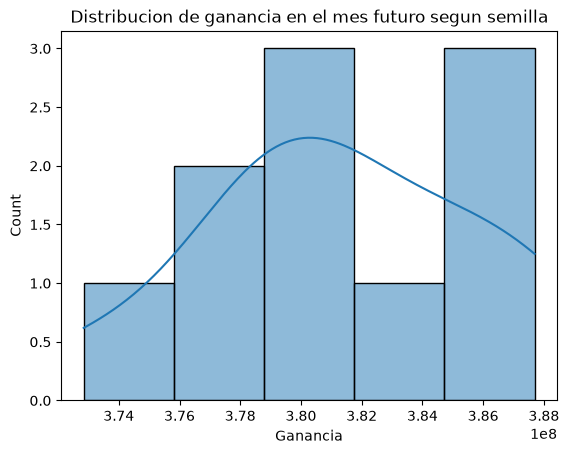

In [18]:
sns.histplot(ganancias_semillas, kde=True)
plt.title('Distribucion de ganancia en el mes futuro segun semilla')
plt.xlabel('Ganancia')
plt.show()


### 4) Sanity check: ruido puro


In [19]:
np.random.seed(semilla)
X_df = pd.DataFrame(Xi, columns=X.columns)
ruido = pd.DataFrame({f'ruido_{i}': np.random.rand(len(X_df)) for i in range(1, 6)})
X_con_ruido = pd.concat([X_df, ruido], axis=1)

model_ruido = RandomForestClassifier(
    n_estimators=n_estimators_final,
    **study.best_params,
    max_samples=0.7,
    random_state=semillas[0],
    n_jobs=-1,
)
model_ruido.fit(X_con_ruido, y)

imp_ruido = pd.DataFrame({
    'feature': X_con_ruido.columns,
    'importance': model_ruido.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('Posicion de las columnas de ruido en el ranking de importancia:')
print(imp_ruido[imp_ruido['feature'].str.startswith('ruido_')])
print(f"\n(de {len(imp_ruido)} columnas en total)")


Posicion de las columnas de ruido en el ranking de importancia:
    feature  importance
39  ruido_4    0.004704
48  ruido_3    0.003813
51  ruido_1    0.003648
52  ruido_5    0.003480
54  ruido_2    0.003283

(de 237 columnas en total)


### 5) Cuanto aportan las features nuevas de `clase4`


In [20]:
importances = model_rf.feature_importances_
feat_importances = pd.DataFrame({'feature': X.columns, 'importance': importances})
feat_importances = feat_importances.sort_values('importance', ascending=False).reset_index(drop=True)

prefijos_nuevos = ('tc_', 'r_', 'dig_', 'prod_', 'rank_', 'lag_', 'delta_', 'ma_', 'slope_')
feat_importances['es_nueva'] = feat_importances['feature'].str.startswith(prefijos_nuevos)

importancia_por_grupo = feat_importances.groupby('es_nueva')['importance'].sum()
pct_nuevas = importancia_por_grupo.get(True, 0) * 100
print(f"% de importancia capturada por features nuevas de clase4: {pct_nuevas:.1f}%")

print("\nTop 15 features nuevas por importancia:")
display(feat_importances[feat_importances['es_nueva']].head(15))

print("\nTop 15 features en general:")
display(feat_importances.head(15))


% de importancia capturada por features nuevas de clase4: 53.9%

Top 15 features nuevas por importancia:


,feature,importance,es_nueva
1,rank_ctrx_quarter,0.070338,True
2,ma_3_mcuentas_saldo,0.047568,True
3,ma_3_rank_ctrx_quarter,0.046408,True
6,rank_mcuentas_saldo,0.035565,True
9,ma_3_ctrx_quarter,0.030628,True
10,ma_3_rank_mcuentas_saldo,0.030414,True
11,prod_total_prestamos,0.026163,True
12,lag_1_ctrx_quarter,0.023363,True
13,r_endeudamiento_saldo,0.022107,True
15,lag_1_rank_ctrx_quarter,0.021448,True



Top 15 features en general:


,feature,importance,es_nueva
0,ctrx_quarter,0.096113,False
1,rank_ctrx_quarter,0.070338,True
2,ma_3_mcuentas_saldo,0.047568,True
3,ma_3_rank_ctrx_quarter,0.046408,True
4,cproductos,0.038922,False
5,mprestamos_personales,0.035937,False
6,rank_mcuentas_saldo,0.035565,True
7,mcuentas_saldo,0.032776,False
8,ctarjeta_master,0.030763,False
9,ma_3_ctrx_quarter,0.030628,True


## Conclusion

El modelo final queda elegido no por el numero puntual de ganancia en el mes futuro, sino por el conjunto: una distribucion de ganancia estable entre semillas (paso 2), un gap train/mayo razonable (paso 3, comparado contra `z401`), evidencia de que se apoya en senal real y no en ruido (paso 4), y una fraccion no trivial de importancia en las features nuevas de `clase4` (paso 5) frente al baseline de `z401` sin feature engineering (paso 6). Si algun otro juego de hiperparametros de Optuna da una distribucion con media similar pero menor varianza, o un gap train/mayo mas chico, es preferible a este aunque su ganancia puntual sea un poco menor.
